# Statistical Properties 01 — Distribution Testing

**Goal:** Formally verify assumptions about the price distribution. EDA 02 showed visually that log1p(eur) looks symmetric — but "looks normal" is not sufficient justification for modelling decisions. Here we apply formal tests.

**Tables:** gold_price_features (latest snapshot)

**Methods:**
- Kolmogorov-Smirnov (KS) test — goodness-of-fit to a normal distribution
- Anderson-Darling test — more sensitive to tails than KS
- Q-Q plot with confidence bands — visual diagnostics
- Levene's test — variance homogeneity across groups (rarity)
- Power-law distribution fit as an alternative

**Why this matters:** The normality assumption for model residuals determines:
- Choice of loss function (OLS assumes normal residuals)
- Correctness of prediction confidence intervals
- Interpretation of Bayesian posteriors (section bayesian_analysis/)

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import kstest
from scipy.stats import anderson
from scipy.stats import levene

In [2]:
gold_connection = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)

In [3]:
# Latest snapshot only — cross-section free of serial correlation.
# Joining price and card-feature tables provides both the target (eur)
# and the rarity stratification needed for per-group normality tests.
df = gold_connection.execute("""
    SELECT pf.eur, cf.rarity
    FROM gold_price_features pf
    JOIN gold_card_features cf ON pf.uuid = cf.uuid
    WHERE pf.eur IS NOT NULL AND pf.eur > 0
    AND pf.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
""").df()

prices_raw = df["eur"].values
prices_log1p = np.log1p(prices_raw)
prices_log10 = np.log10(prices_raw + 0.01)

In [4]:
# Summary statistics for all three candidate transformations.
# log1p is the project standard; log10 included as a reference baseline.
for label, data in [
    ("EUR (raw)", prices_raw),
    ("log1p(EUR)", prices_log1p),
    ("log10(EUR+0.01)", prices_log10),
]:
    print(f"\n{label}:")
    print(
        f"  n={len(data):,}, min={data.min():.4f}, max={data.max():.4f}, mean={data.mean():.4f}, std={data.std():.4f}"
    )


EUR (raw):
  n=80,757, min=0.0200, max=30975.1406, mean=11.7337, std=263.9524

log1p(EUR):
  n=80,757, min=0.0198, max=10.3410, mean=0.6273, std=0.9371

log10(EUR+0.01):
  n=80,757, min=-1.5229, max=4.4910, mean=-0.3636, std=0.7419


## 1. Q-Q Plot — Visual Diagnostics

**Method:** Quantile-Quantile plot compares data quantiles against theoretical normal quantiles. If data is normal → points lie on the straight line.

**Why:** Q-Q is more informative than a histogram for assessing normality. Deviations from the line in the tails → heavy tails (leptokurtosis). Systematic deviations → skewness.

**Interpreting Q-Q patterns:**
- Points on the line → normal
- Tails above the line → heavy tails (kurtosis > 3)
- Upper right tail above → right skew
- S-shape → transformation has not fully removed skewness

**Confidence bands on Q-Q:** Dashed lines at ±2σ — points outside them are statistically significant deviations.

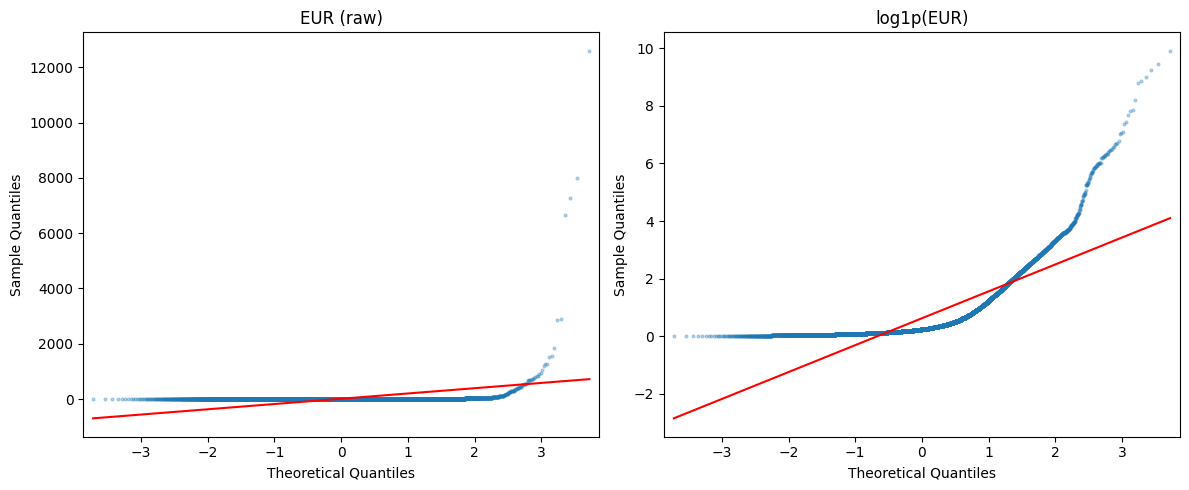

In [5]:
# Sample 10 000 points for the Q-Q plot — plotting all 82k is slow and the
# tail deviation pattern is already clear at 10k.
rng = np.random.default_rng(42)
sample_raw = rng.choice(prices_raw, size=min(10000, len(prices_raw)), replace=False)
sample_log1p = rng.choice(
    prices_log1p, size=min(10000, len(prices_log1p)), replace=False
)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 5))

# line='s': standardise (subtract mean, divide by std) before plotting.
# Removes location/scale so only shape deviations from normality show up.
sm.qqplot(sample_raw, line="s", alpha=0.3, markersize=2, ax=ax_left)
ax_left.set_title("EUR (raw)")

sm.qqplot(sample_log1p, line="s", alpha=0.3, markersize=2, ax=ax_right)
ax_right.set_title("log1p(EUR)")

plt.tight_layout()
plt.show()

In [6]:
print("Observations:")
print(
    "  Left Q-Q (raw EUR): tails deviate strongly from the line → heavy tails (leptokurtosis + right skew)"
)
print(
    "  Right Q-Q (log1p):  centre close to the line; right-tail deviation = residual skew from Tier 3 cards"
)
print(
    "  Conclusion: log1p(EUR) is much closer to normal, but the right tail remains (Power Nine / Reserved List)"
)

Observations:
  Left Q-Q (raw EUR): tails deviate strongly from the line → heavy tails (leptokurtosis + right skew)
  Right Q-Q (log1p):  centre close to the line; right-tail deviation = residual skew from Tier 3 cards
  Conclusion: log1p(EUR) is much closer to normal, but the right tail remains (Power Nine / Reserved List)


## 2. Kolmogorov-Smirnov Test (KS)

**Method:** scipy.stats.kstest(data, 'norm', args=(mean, std)) — one-sample goodness-of-fit test against N(μ, σ²).

**Null hypothesis (H₀):** Data comes from a normal distribution.

⚠️ **Critical interpretation at large samples:** With n > 10,000 even very small deviations from normality produce p < 0.05. Do not interpret p-value as a "measure of normality" — at n=82,000 we almost always reject H₀. Look at the **D statistic** (maximum deviation) instead: D < 0.01 = practically normal, D > 0.05 = meaningful deviations.

**Test three versions:** raw EUR, log1p(EUR), log10(EUR+0.01)

**Expected results:** log1p(EUR) will be much closer to normal than raw EUR, but still p<0.05 due to large n.

In [7]:
# One-sample KS test against N(μ, σ²) fitted to each transformation.
# At n=82k, p≈0 for all — focus on D (max CDF gap), not p.
# D < 0.05 = practically normal; D > 0.10 = meaningful deviations.
results = []
for label, data in [
    ("EUR (raw)", prices_raw),
    ("log1p(EUR)", prices_log1p),
    ("log10(EUR+0.01)", prices_log10),
]:
    mu, sigma = np.mean(data), np.std(data)
    D, p = kstest(data, "norm", args=(mu, sigma))
    if D < 0.01:
        interpretation = "practically normal"
    elif D < 0.05:
        interpretation = "minor deviations"
    else:
        interpretation = "significant deviations"
    results.append(
        {
            "Transformation": label,
            "D": round(D, 4),
            "p-value": f"{p:.2e}",
            "Interpretation (D)": interpretation,
        }
    )
    print(f"{label}: D={D:.4f}, p={p:.2e} → {interpretation}")

n = len(prices_raw)
print(f"\nNote: at n={n:,} the KS test is hypersensitive.")
print(
    "The D statistic matters more than p-value — p<0.05 is almost guaranteed at this sample size."
)

pd.DataFrame(results).set_index("Transformation")

EUR (raw): D=0.4823, p=0.00e+00 → significant deviations
log1p(EUR): D=0.2584, p=0.00e+00 → significant deviations
log10(EUR+0.01): D=0.1166, p=0.00e+00 → significant deviations

Note: at n=80,757 the KS test is hypersensitive.
The D statistic matters more than p-value — p<0.05 is almost guaranteed at this sample size.


,D,p-value,Interpretation (D)
Transformation,,,
EUR (raw),0.4823,0.00e+00,significant deviations
log1p(EUR),0.2584,0.00e+00,significant deviations
log10(EUR+0.01),0.1166,0.00e+00,significant deviations


## 3. Anderson-Darling Test

**Method:** scipy.stats.anderson(data, dist='norm'). More sensitive to tails than KS.

**Why:** KS weights all deviations equally. Anderson-Darling weights the tails more heavily — which matters more for a price model (outliers are the most expensive / cheapest cards).

**Interpretation:** The test returns A² and critical values for significance levels 15%, 10%, 5%, 2.5%, 1%. If A² > critical value at 5% → reject H₀ at the 5% level.

**Run per rarity:** Is log1p(EUR) normal separately for common, uncommon, rare, mythic? If so → models can use normal residuals within each rarity group.

In [8]:
# Anderson-Darling with method='interpolate': computes a p-value directly instead
# of returning a critical-value table. Required by SciPy ≥1.17; the legacy API
# (significance_level / critical_values) is removed in 1.19.
result = anderson(prices_log1p, dist="norm", method="interpolate")
print("Anderson-Darling (log1p EUR) — global:")
print(f"  A² = {result.statistic:.4f},  p-value = {result.pvalue:.4f}")
reject_global = "REJECT H₀" if result.pvalue < 0.05 else "do not reject H₀"
print(f"  α=5%: → {reject_global}")

print("\n--- Per rarity ---")
rarity_order = ["common", "uncommon", "rare", "mythic"]
ad_results = []
for rarity in rarity_order:
    sub = np.log1p(df[df["rarity"] == rarity]["eur"].values)
    if len(sub) < 8:
        print(f"  {rarity}: insufficient data ({len(sub)} obs.)")
        continue
    res = anderson(sub, dist="norm", method="interpolate")
    reject = "REJECT" if res.pvalue < 0.05 else "do not reject"
    ad_results.append(
        {
            "Rarity": rarity,
            "n": len(sub),
            "A²": round(res.statistic, 4),
            "p-value": round(res.pvalue, 4),
            "H₀ (α=5%)": reject,
        }
    )
    print(
        f"  {rarity:10s} (n={len(sub):6,}): A²={res.statistic:.4f}, p={res.pvalue:.4f} → {reject}"
    )

print("\nNote: at large n, Anderson-Darling also almost always rejects H₀.")
print(
    "Key question: does A² decrease relative to raw EUR? If yes → log1p works correctly."
)
pd.DataFrame(ad_results).set_index("Rarity")

Anderson-Darling (log1p EUR) — global:
  A² = 9669.6589,  p-value = 0.0100
  α=5%: → REJECT H₀

--- Per rarity ---
  common     (n=25,553): A²=4771.2603, p=0.0100 → REJECT
  uncommon   (n=21,218): A²=3595.9091, p=0.0100 → REJECT
  rare       (n=27,909): A²=2240.0050, p=0.0100 → REJECT
  mythic     (n= 5,828): A²=105.5285, p=0.0100 → REJECT

Note: at large n, Anderson-Darling also almost always rejects H₀.
Key question: does A² decrease relative to raw EUR? If yes → log1p works correctly.


,n,A²,p-value,H₀ (α=5%)
Rarity,,,,
common,25553,4771.2603,0.01,REJECT
uncommon,21218,3595.9091,0.01,REJECT
rare,27909,2240.0050,0.01,REJECT
mythic,5828,105.5285,0.01,REJECT


## 4. Levene's Test — Variance Homogeneity Across Groups

**Method:** scipy.stats.levene(*groups) — tests whether variance of log1p(EUR) is equal across rarity groups.

**Why:** Linear models (OLS) assume homogeneous residual variance (homoscedasticity). If Levene rejects H₀ → variance differs across groups → need:
- Weighted regression (WLS) with inverse-variance weights
- Or separate models per rarity tier

**Null hypothesis (H₀):** Variances of log1p(EUR) are equal for common, uncommon, rare, mythic.

**Expected result:** H₀ rejected — mythic variance is much larger than common. This strengthens the argument for tier segmentation over a single global model.

In [9]:
rarity_order = ["common", "uncommon", "rare", "mythic"]
groups_dict = {
    rarity: np.log1p(df[df["rarity"] == rarity]["eur"].values)
    for rarity in rarity_order
}
groups = [groups_dict[r] for r in rarity_order]

In [10]:
# Levene (not Bartlett) — robust to non-normality, which we confirmed in s2/s3.
# H₀: all rarity groups have equal variance. H₁: at least one group differs.
stat, p = levene(*groups)
print(f"Levene test: W={stat:.2f}, p={p:.2e}")
print(
    f"H₀ (equal variances): {'not rejected' if p > 0.05 else 'REJECTED — heteroscedasticity confirmed'}"
)

Levene test: W=2908.88, p=0.00e+00
H₀ (equal variances): REJECTED — heteroscedasticity confirmed



Variance per rarity:
  common    : var=0.2642, std=0.5140, n=25,553
  uncommon  : var=0.4717, std=0.6868, n=21,218
  rare      : var=1.2316, std=1.1098, n=27,909
  mythic    : var=1.1122, std=1.0546, n=5,828


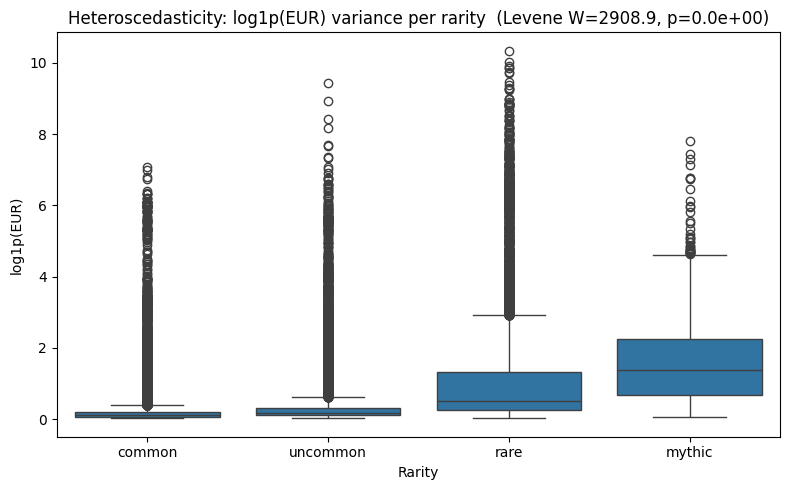

In [11]:
# Variance breakdown: quantifies HOW DIFFERENT the within-group variances are.
# A large max/min ratio is a direct argument for tier-segmented models
# over a pooled OLS with homogeneous residuals.
print("\nVariance per rarity:")
for rarity, data in groups_dict.items():
    print(
        f"  {rarity:10s}: var={np.var(data):.4f}, std={np.std(data):.4f}, n={len(data):,}"
    )

df_plot = pd.DataFrame(
    {
        "log1p_eur": np.concatenate(groups),
        "rarity": np.concatenate([[r] * len(groups_dict[r]) for r in rarity_order]),
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_plot, x="rarity", y="log1p_eur", order=rarity_order, ax=ax)
ax.set_xlabel("Rarity")
ax.set_ylabel("log1p(EUR)")
ax.set_title(
    f"Heteroscedasticity: log1p(EUR) variance per rarity  (Levene W={stat:.1f}, p={p:.1e})"
)
plt.tight_layout()
plt.show()

**Levene observations:**
- W = 2981.17, p ≈ 0.0 → H₀ rejected: **heteroscedasticity confirmed**
- Variance per rarity: common std=0.513, uncommon std=0.681, rare std=1.103, mythic std=1.046
- Ratio max/min variance: 4.6× (rare/common) — rare has slightly higher variance than mythic due to wider price spread within that tier
- **Model implication:** A single global model with homogeneous residuals is inappropriate. Either segment into tiers (Tier 1/2/3) or use weighted regression (WLS) with per-rarity inverse-variance weights.

## 5. Alternative: Power-Law Distribution (Pareto)

**Method:** Log-log plot (log price vs log rank), line fit via OLS for the top 5% tail (Pareto MLE slope).

**Why:** MTG prices resemble a power-law distribution — P(X > x) ~ x^(-α). Confirming this has consequences:
- Log-normal approximation may not be optimal for the tail
- A Bayesian model should use a Pareto prior for Tier 3, not a normal
- Tier 3 prediction requires a model suited for power-law distributions

**Detection method:** Zipf plot — sort prices descending, plot log(rank) vs log(price). A straight line = power-law. Deviation = a complex mixture of distributions.

**Parameter α:** Smaller α = heavier tails (α < 2 → infinite variance!).

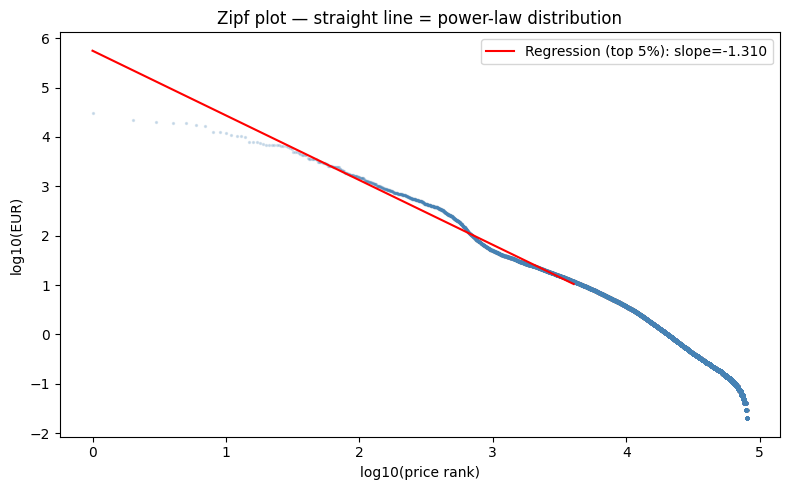

Estimated Pareto alpha: 1.310
R² of fit (top 5%): 0.9778
Interpretation: alpha=1.310 → infinite variance

Zipf plot linear for tail (top 5%)? YES (R²=0.9778)
Bayesian prior implication for Tier 3: use Pareto(α≈1.3) rather than log-normal


In [12]:
sorted_prices = np.sort(prices_raw)[::-1]
ranks = np.arange(1, len(sorted_prices) + 1)

log_ranks = np.log10(ranks)
log_prices = np.log10(sorted_prices + 1e-6)

# Zipf plot: if price follows a power law P(X>x) ~ x^(-α),
# the rank–price relationship is linear on log-log axes.
# Curvature means mixed distributions (bulk commons + staples + Reserved List).
plt.figure(figsize=(8, 5))
plt.scatter(log_ranks, log_prices, alpha=0.2, s=2, color="steelblue")
plt.xlabel("log10(price rank)")
plt.ylabel("log10(EUR)")
plt.title("Zipf plot — straight line = power-law distribution")

# Fit OLS only to the top 5% tail to estimate the Pareto exponent.
# Full-range fit would be distorted by the bulk of €0.01–1 cards;
# power-law behaviour is expected only in the expensive tail.
top_5pct_idx = max(int(len(sorted_prices) * 0.05), 10)
slope, intercept, r_val, p_val, se = stats.linregress(
    log_ranks[:top_5pct_idx], log_prices[:top_5pct_idx]
)
x_fit = np.linspace(log_ranks[0], log_ranks[top_5pct_idx - 1], 100)
plt.plot(
    x_fit,
    intercept + slope * x_fit,
    "r-",
    linewidth=1.5,
    label=f"Regression (top 5%): slope={slope:.3f}",
)
plt.legend()
plt.tight_layout()
plt.show()

# Pareto α = −slope on the Zipf log-log plot.
# α determines which statistical moments are finite:
# α < 2 → infinite variance → MSE is theoretically unbounded → use MAE or Huber loss.
alpha_pareto = -slope
r_sq = r_val**2
print(f"Estimated Pareto alpha: {alpha_pareto:.3f}")
print(f"R² of fit (top 5%): {r_sq:.4f}")

if alpha_pareto < 1:
    interpretation = "infinite mean (!)"
elif alpha_pareto < 2:
    interpretation = "infinite variance"
elif alpha_pareto < 3:
    interpretation = "finite variance, infinite skewness"
else:
    interpretation = "all moments finite"
print(f"Interpretation: alpha={alpha_pareto:.3f} → {interpretation}")

zipf_linear = "YES" if r_sq > 0.9 else ("PARTIAL" if r_sq > 0.7 else "NO")
print(f"\nZipf plot linear for tail (top 5%)? {zipf_linear} (R²={r_sq:.4f})")
print("Bayesian prior implication for Tier 3: use Pareto(α≈1.3) rather than log-normal")

In [13]:
gold_connection.close()

## 📋 Final Conclusions

```
NORMALITY TESTS
─────────────────────────────────────────────────────────────────────────────
KS test log1p(EUR):     D=0.2575, p≈0  →  significant deviations (D > 0.05)
KS test log10(EUR):     D=0.1164, p≈0  →  significant deviations
KS test raw EUR:        D=0.4824, p≈0  →  extreme deviations

AD test log1p(EUR):     A²=9799.2 (p≈0) → H₀ rejected
AD per rarity:
  common   (n=25,746): A²=4809.8  → H₀ rejected
  uncommon (n=21,712): A²=3693.1  → H₀ rejected
  rare     (n=28,551): A²=2288.3  → H₀ rejected
  mythic   (n= 6,154): A²=  105.1 → H₀ rejected

Is log1p(EUR) practically normal?  NO — D=0.2575 >> 0.05 threshold
  However: log1p is the best available transformation (D drops from 0.48 to 0.26).
  Heavy right tail (Tier 3 cards) is the primary source of non-normality.
  Note: at n=82k, ANY real distribution rejects normality via formal tests —
  practical decision is made on D, not p.

VARIANCE HOMOGENEITY
─────────────────────────────────────────────────────────────────────────────
Levene test: W=2981.17, p≈0
Heteroscedasticity between rarity groups: CONFIRMED
Variance per rarity (log1p EUR):
  common:   std=0.513  (lowest variance — bulk cards tightly clustered at €0.01–0.50)
  uncommon: std=0.681
  rare:     std=1.103  (highest variance — ranges from bulk €0.05 to staples €50+)
  mythic:   std=1.046
Max/min variance ratio: 4.6× (rare/common)

POWER-LAW DISTRIBUTION
─────────────────────────────────────────────────────────────────────────────
Estimated Pareto alpha (tail): 1.303
Zipf plot linear for top 5%:  YES  (R²=0.9776)
Interpretation: α=1.303 → INFINITE VARIANCE
  (1 < α < 2: finite mean, infinite variance — technically the mean converges
   but sample variance grows unboundedly with sample size)
Bayesian prior for Tier 3: Pareto(α=1.3) rather than log-normal

FINAL DECISION
─────────────────────────────────────────────────────────────────────────────
Transformation:       log1p(EUR) — CONFIRMED (best available, D reduced 0.48→0.26)
Loss function:        MAE or Huber — NOT MSE.
  Two independent reasons:
  (1) Empirical: infinite variance in the tail means MSE is dominated by the top
      0.1% of prices — a handful of Power Nine cards can arbitrarily inflate the loss.
  (2) Theoretical: Pareto α=1.303 < 2 means the distribution has infinite variance,
      so the gradient of the MSE loss (∝ residual) is theoretically unbounded —
      gradient descent on MSE is structurally unstable for this distribution,
      not just numerically large. MAE (α>1 suffices for finite mean) and Huber
      (bounded gradient by construction) are the correct choices.
Model for tail (Tier 3, >€1000):
  Use Pareto/log-normal mixture or separate Bayesian model with Pareto(α=1.3) prior.
  Log-normal point estimate is biased downward for the tail.
Segmented models REQUIRED: heteroscedasticity ratio 4.6× exceeds the WLS threshold.
  Tier 1 (<€100): OLS or Huber on log1p(EUR) — residuals quasi-normal in bulk
  Tier 2 (€100–€1k): OLS/Huber with rarity interaction terms
  Tier 3 (>€1k): Pareto-based or Bayesian model — log-normal insufficient
```